In [33]:
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.stats import chi2

In [34]:
growth_analysis = pd.read_csv('../Datasets/Exercise2_datasets/Exercise7DATA.csv', sep = '\t') \
    .rename(
        columns = { 'gene_5211': 'gene_A',
                    'gene_5091': 'gene_B',
                    'gene_1653': 'gene_C'}) \
    .loc[:, ['strain', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']]

growth_analysis.head()

,strain,growth_rate,gene_A,gene_B,gene_C
0,seg_01B,6.720447,False,False,True
1,seg_01C,7.429273,False,False,True
2,seg_01D,6.905589,True,True,False
3,seg_02B,4.924324,False,True,False
4,seg_02C,4.413402,False,False,True


------
# Section 02 - Test the association between markers and growth

1. Reproduce the growth boxplot for gene A using the following code:

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


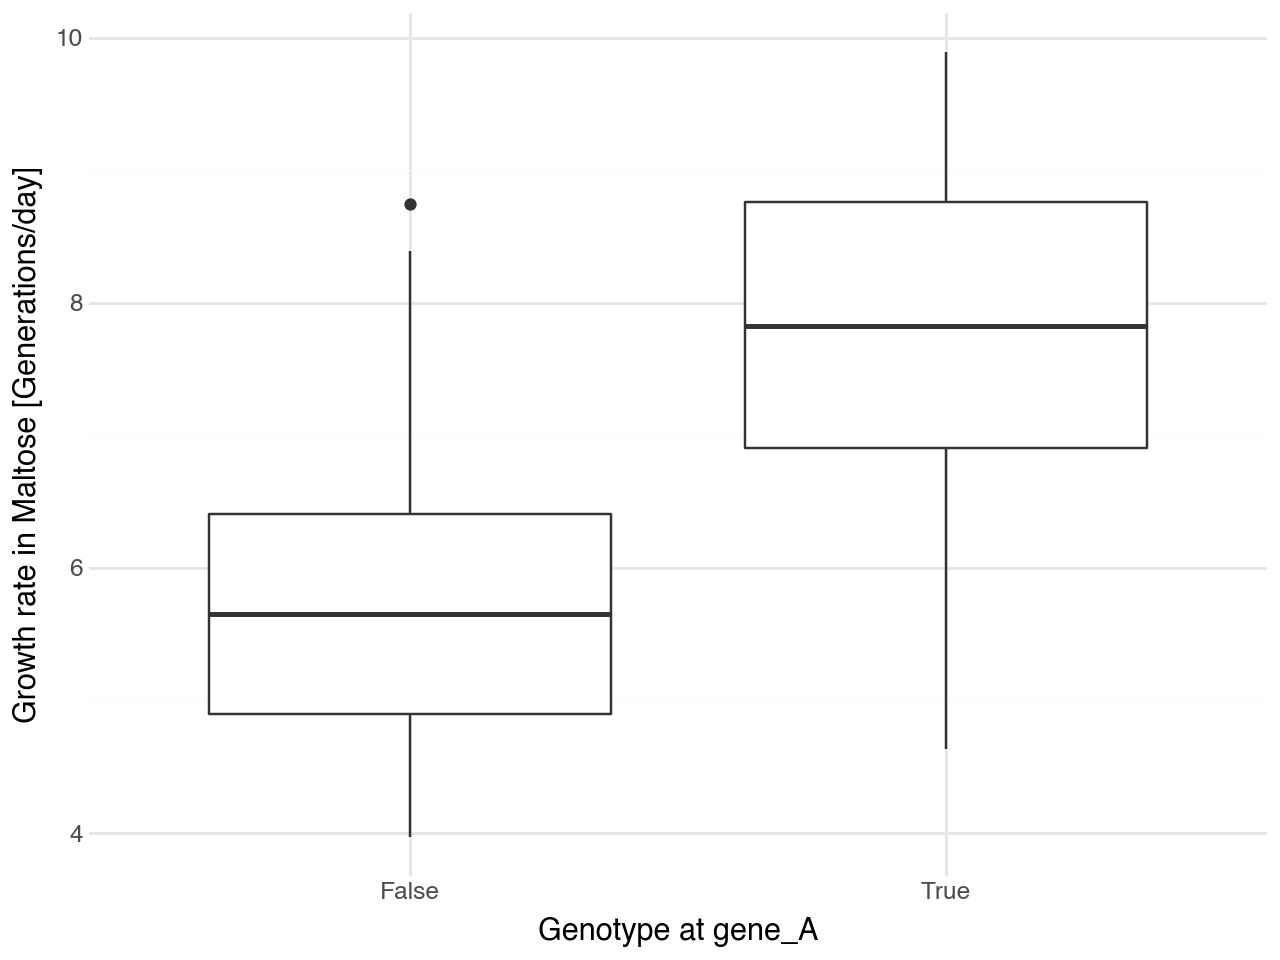

In [35]:
def plot_growth_one_mk(growth_analysis, gene):
    plot = (
        ggplot(growth_analysis, aes(gene, 'growth_rate')) +
        geom_boxplot() +
        xlab(f"Genotype at {gene}") +
        ylab("Growth rate in Maltose [Generations/day]") +
        theme_minimal()
    )
    return plot

plot_growth_one_mk(growth_analysis, 'gene_A')

2. Last week, using permutation, we saw that some genes are associated with growth. Which of the
statistical tests from the lecture would you use to test this association?

For each gene, we are not certain if it has a positive or negative effect on growth; therefore, which kind
of alternative hypothesis would you choose: double-sided, right or left? Apply the test(-s) to gene A to
obtain a p-value and see if the association that we found last week still holds. If more than one of the
tests are appropriate, specify, what are the assumptions, that you are doing in each case, use them all
and compare the results.

To not make any distributional assumptions it is best to use the Wilcoxon rank-sum test here. Since the
growth can be affected in both directions, we choose double-sided alternative.

In [36]:
from scipy.stats import mannwhitneyu

x1 = growth_analysis[growth_analysis['gene_A']]['growth_rate']
x2 = growth_analysis[~growth_analysis['gene_A']]['growth_rate']

mw_text = mannwhitneyu(x1,x2, alternative= 'two-sided', nan_policy= 'omit')

print(mw_text)

MannwhitneyuResult(statistic=np.float64(5230.0), pvalue=np.float64(2.2643864924854154e-16))


For completeness, we also give the results for using a t-test. This requires an assumption of normality,
which possibly can be justified by appealing to the number of observations in each group being sufficiently
large so that the Central Limit Theorem applies. In Python, the t-test can be run with or without Welch’s
correction:

In [37]:
from scipy.stats import ttest_ind

## Student's t-Test without Welch correction
tt = ttest_ind(x1, x2, equal_var=True, nan_policy='omit')
print(tt)

TtestResult(statistic=np.float64(10.77022615309119), pvalue=np.float64(1.8649474458373772e-20), df=np.float64(152.0))


3. Given a gene and the name of a statistical test, make a function that returns the p-value of the
association of that gene with respect to growth. You can use the template below to construct this
function. Then test your function on the genes B and C. Since we used the same markers last week: do
you get similar results as last week?

In [38]:
def test_growth(gene_name, test):
    x1 = growth_analysis[growth_analysis[gene_name]]['growth_rate']
    x2 = growth_analysis[~growth_analysis[gene_name]]['growth_rate']

    from scipy.stats import ttest_ind, mannwhitneyu

    if test == 'wilcoxon':
        pval = mannwhitneyu(x1,x2, alternative= 'two-sided', nan_policy= 'omit').pvalue
    else:
        pval = ttest_ind(x1, x2, equal_var= False, nan_policy= 'omit').pvalue
    
    return pval

In [39]:
print(test_growth('gene_B','wilcoxon'))
print(test_growth('gene_B','t'))
print(test_growth('gene_C','wilcoxon'))
print(test_growth('gene_C','t'))

0.0008088140351615149
0.0006307450542089743
0.5009288407539181
0.497171274537874


# Section 03 - Correlations and correlation tests

1. Investigate the Pearson correlation between Sepal.Length and Sepal.Width within the iris dataset
(you can load the dataset from seaborn library using load_dataset({dataset_name}) function). Calculate the correlation and plot your results. Are there any issues with your results? Discuss.

In [41]:
import seaborn as sns
from scipy.stats import pearsonr

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [46]:
r, p_value = pearsonr(iris['sepal_length'], iris['sepal_width'])
print(f'Pearson R: {r:.4f}\nP_value: {p_value:.4f}')

Pearson R: -0.1176
P_value: 0.1519


In [49]:
pearson_r = iris['sepal_length'].corr(iris['sepal_width'])
print(f'Pearson R: {pearson_r:.4f}')

Pearson R: -0.1176


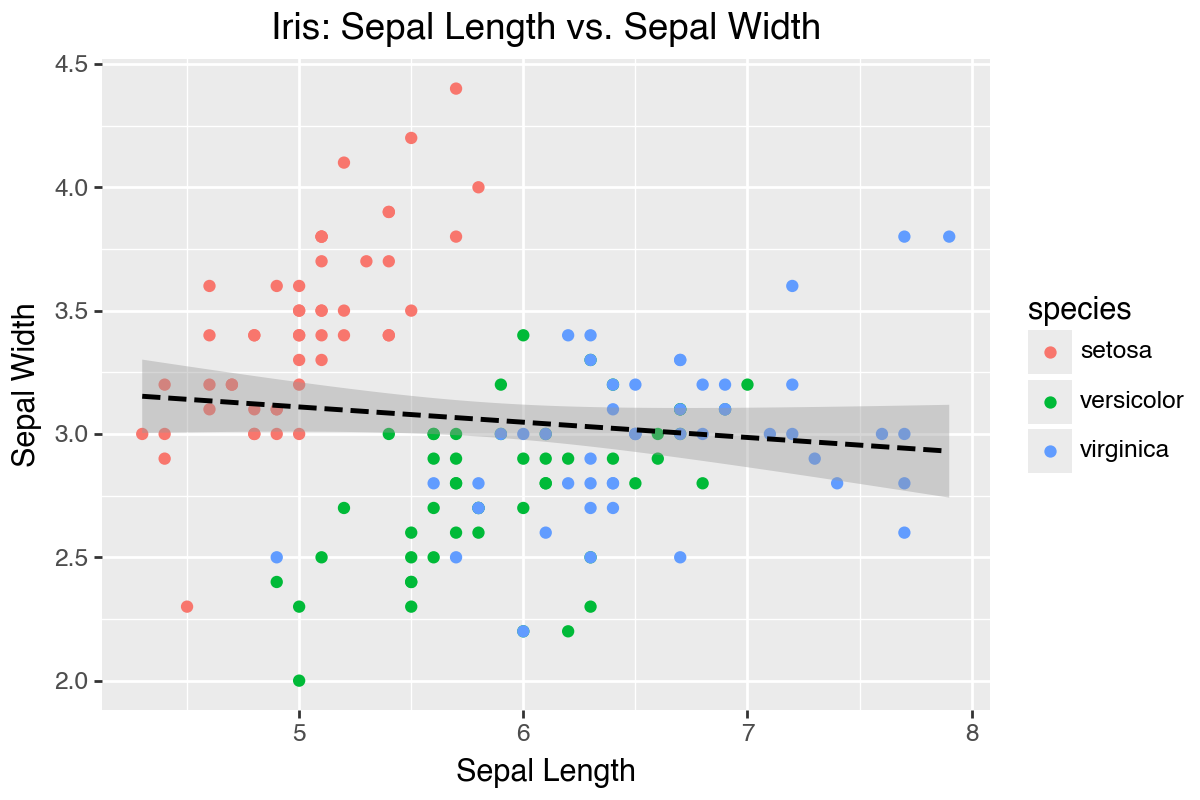

In [57]:
(
    ggplot(iris, aes('sepal_length', 'sepal_width', color = 'species')) + 
    geom_point() +
    geom_smooth(method = 'lm', color = 'black', linetype = 'dashed') + 
    labs(title='Iris: Sepal Length vs. Sepal Width', x='Sepal Length', y='Sepal Width') +
    theme(figure_size=(6,4))
)

We obtain a negative correlation!!??

The data can depend on multiple variables, i.e different plant species. In this case the correlation of the
data is confounded. To assess correlation we can run the analysis for each group individually.

2. Repeat the previous analysis for each species independently. How does the correlation between
Sepal.Length and Sepal.Width change?

In [72]:
iris.groupby('species').apply(
    lambda g : pd.Series(
        pearsonr(g['sepal_length'],(g['sepal_width'])),
        index = ['corr', 'p_value']
    )
).reset_index()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_14545/1899659750.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,species,corr,p_value
0,setosa,0.742547,6.709843e-10
1,versicolor,0.525911,8.771860e-05
2,virginica,0.457228,8.434625e-04


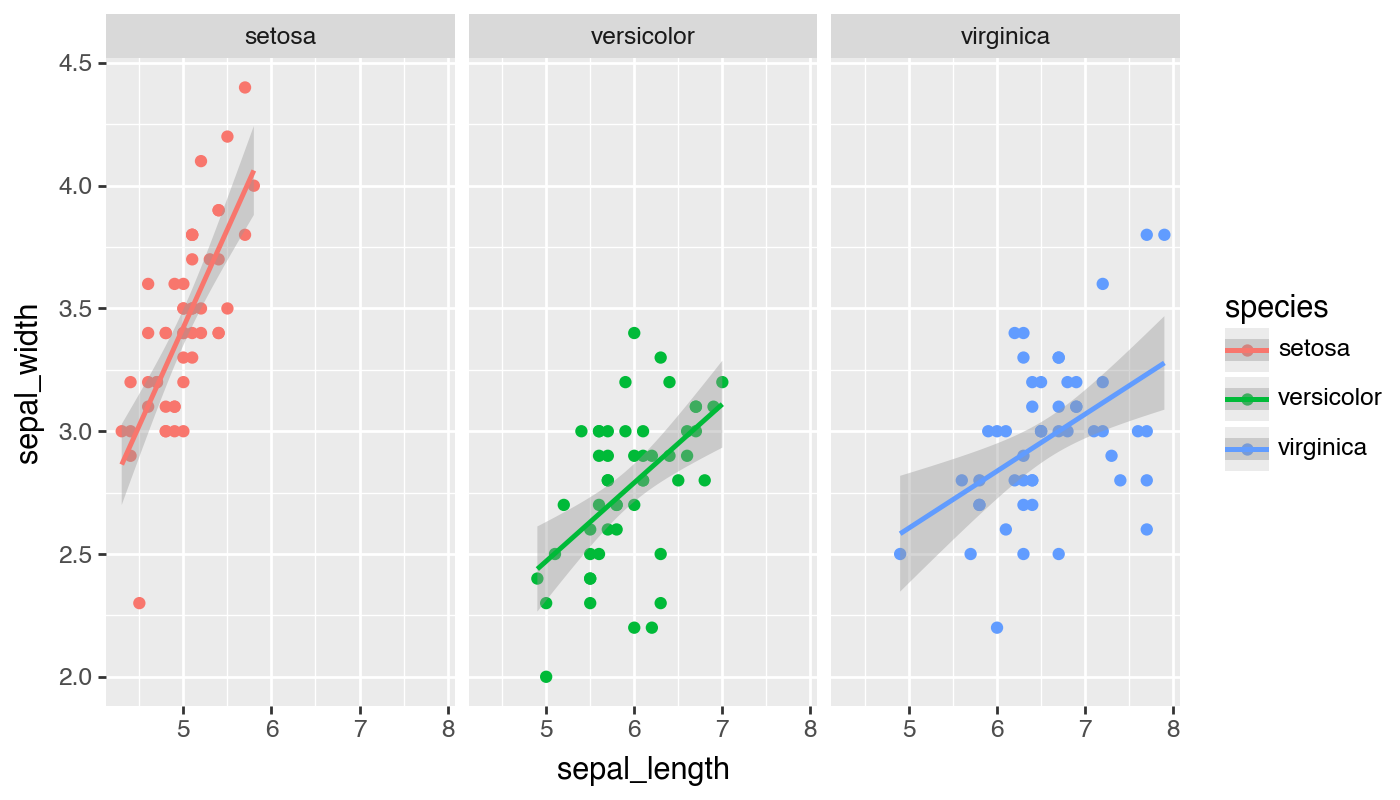

In [75]:
(
    ggplot(iris, aes('sepal_length', 'sepal_width', color = 'species')) + 
    geom_point() + 
    geom_smooth(method = 'lm') + 
    facet_wrap('~species') + 
    theme(figure_size=(7,4))
)

Since the different species are treated independently the correlation is not confounded anymore.

# Section 04 - Warmup: correctly specifying a test

1. A clinical trial was conducted in datavizland to test the efficacy of a new vaccine in preventing viral
infection. The results are summarized in the following contingency table:

<img src = '../images/Ekran Resmi 2026-02-09 23.09.40.png' width = 400>

Suggest an appropriate statistical test, state the null hypothesis and the alternative. Justify, in one
sentence, why you used this test.

Appropriate test is Fisher.

Null hypothesis: Taking the vaccine is not associatedwith reduced chance of infection

Alternative: Taking the vaccine is associated with reduced chance of infection
We use the Fisher with a one-sided alternative as we have two binary variables and the question asks to
test only for a negative association

2. Suppose the above test returns a P-value of 0.00001. Does this imply that the “new vaccine prevents
viral infection”?

Solution:

The test result implies that any negative association we see in the data was unlikely to be the productof
pure chance.

The question above is about causality which the test alone cannot answer.

This critically depends on how the underlying clinical trial was conducted.

# Section 05 - Pitfalls when data deviates from the assumption of normality

1. The file stats-pitfalls.csv contains simulated data that will help us analyze how the t-test can
fail. Load and visualize the data. Use the vizualization approach, that you’ve learned during previous
lectures, to assess the hypothesis, that the data comes from normal distribution. Apply both the t-test
and Wilcoxon test on it.

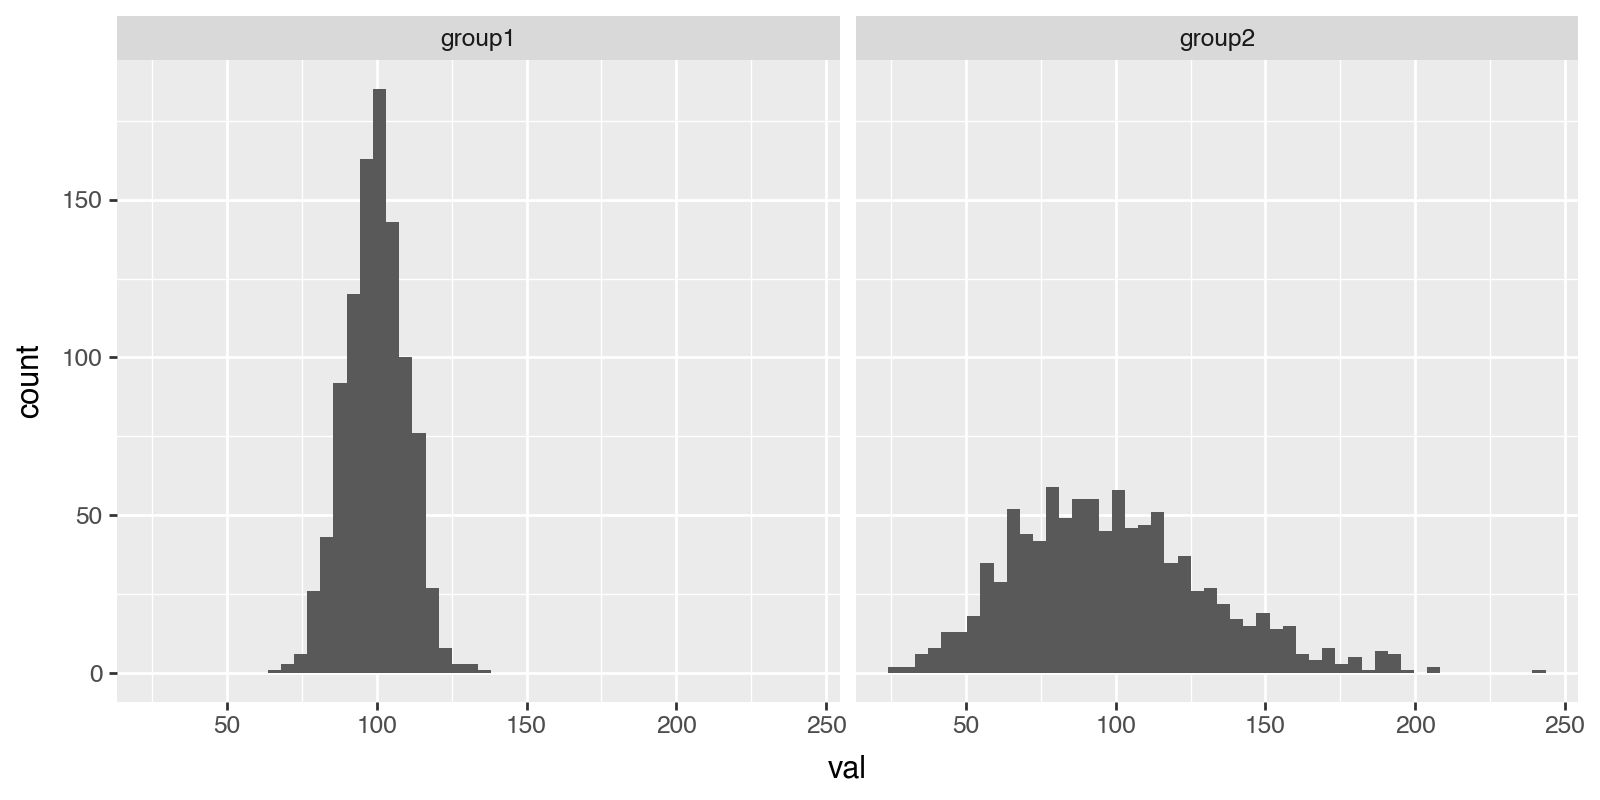

In [86]:
df = pd.read_csv('../Datasets/ExData8/stats-pitfalls.csv', sep = ' ')

(
    ggplot(df.melt(var_name= 'group', value_name= 'val'), aes('val')) + 
    geom_histogram(bins = 50) + 
    facet_wrap('~group') + 
    theme(figure_size=(8,4))
)

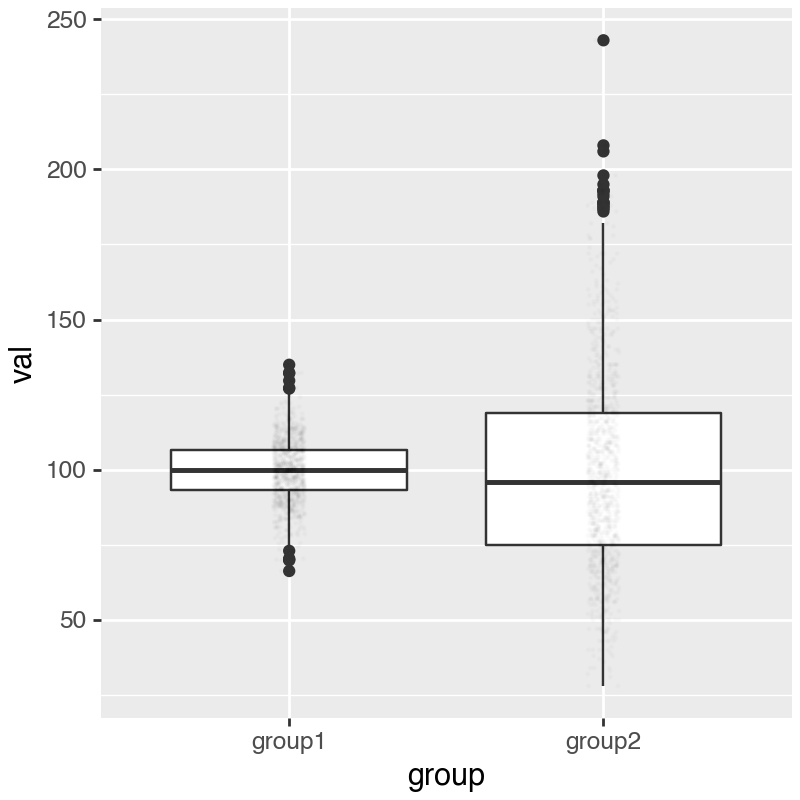

In [93]:
(
    ggplot(df.melt(var_name= 'group', value_name= 'val'), aes('group', 'val')) +
    geom_boxplot() +
    geom_jitter(width = 0.05, alpha = 0.01, size = 0.1) + 
    theme(figure_size=(4,4)) 
)

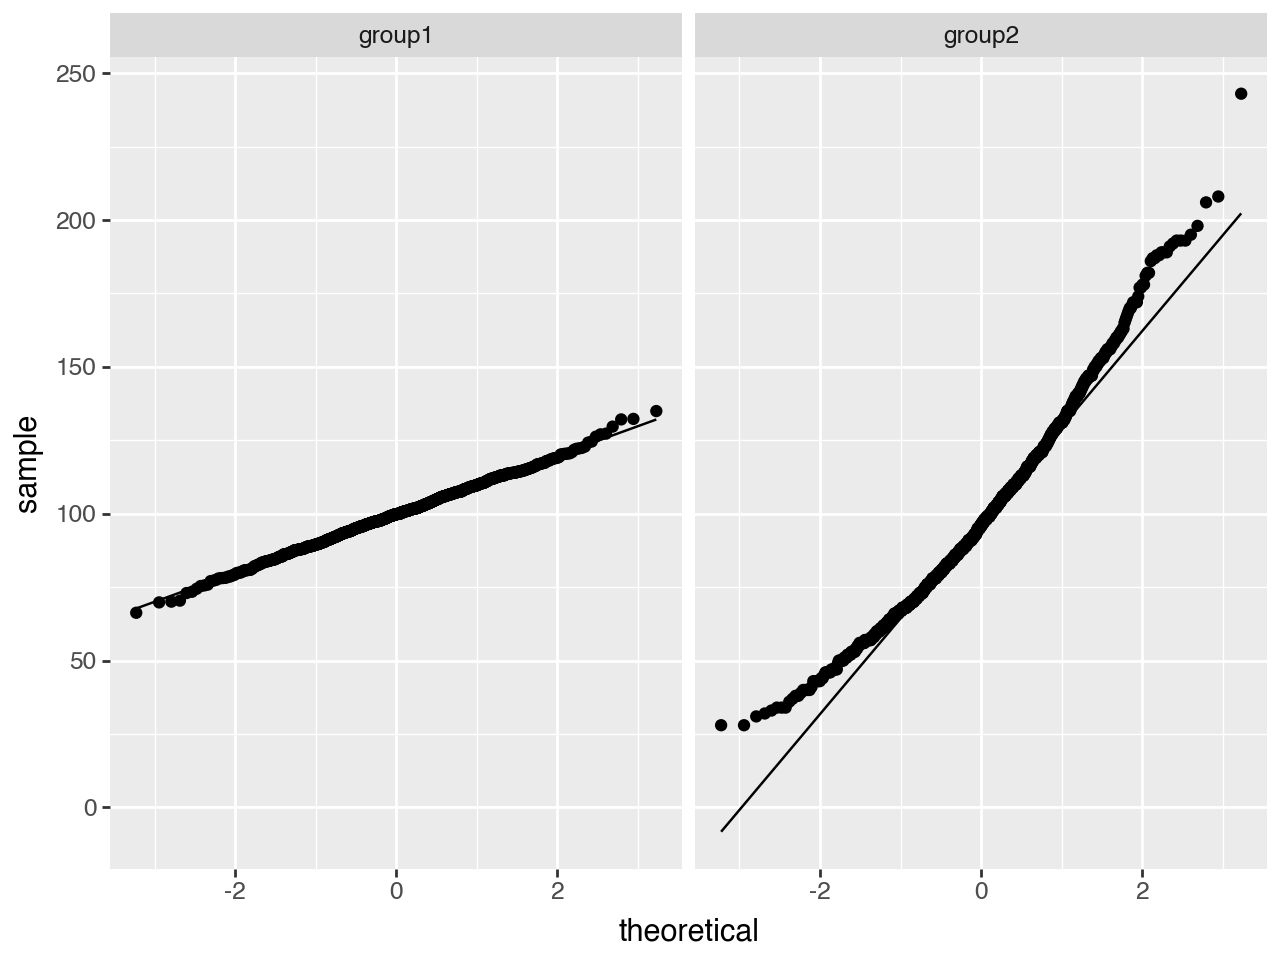

In [97]:
(
    ggplot(df.melt(var_name = 'group', value_name= 'val'), aes(sample = 'val')) +
    geom_qq_line() +
    geom_qq() + 
    facet_wrap('~group')
)

As you can see, the second group doesn’t seem to be following normal distribution. Now let’s apply t-test
and Wilcoxon test to both groups and compare the results.

In [100]:
from scipy.stats import mannwhitneyu, ttest_ind

wilcox_p = mannwhitneyu(df['group1'], df['group2']).pvalue
ttest_p  = ttest_ind(df['group1'], df['group2']).pvalue

print(f'wilcox_p: {wilcox_p:.4f}')
print(f'ttest_p : {ttest_p:.4f}')

wilcox_p: 0.0016
ttest_p : 0.6625


Which test is correct? Let’s investigate the data further.

The boxplot uses the median and not the mean. Therefore we can add the mean to it and look at the
data again:

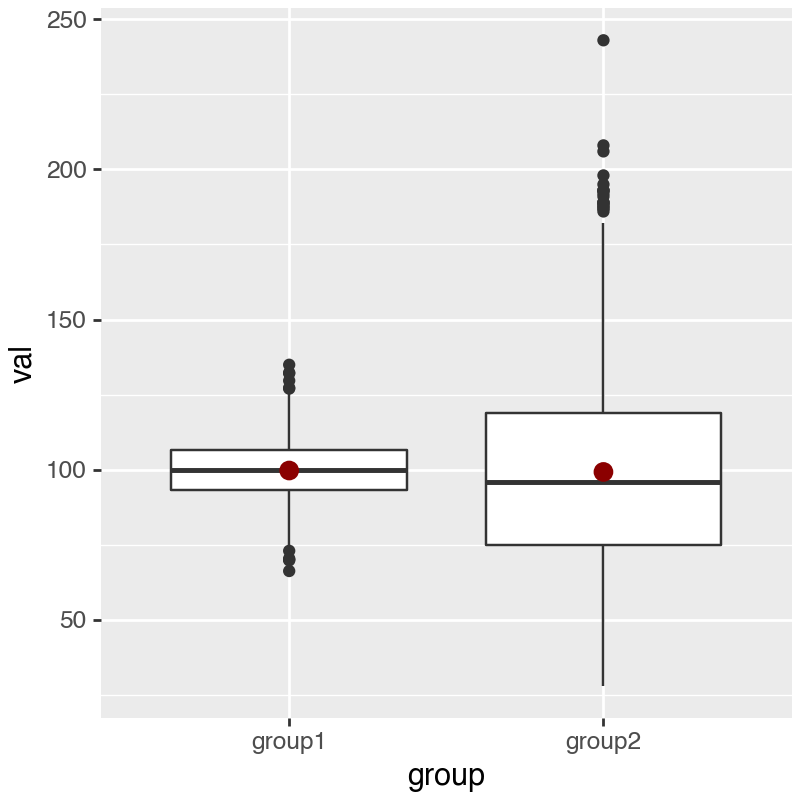

In [103]:
(
    ggplot(df.melt(var_name= 'group', value_name= 'val'), aes('group', 'val')) +
    geom_boxplot() + 
    stat_summary(fun_y=np.mean, geom="point", color="darkred", size=3) +
    theme(figure_size= (4,4))
)

The t-test only compares the mean of each group and clearly the mean of both groups is basically the
same.

If both groups followed normal distributions, this would imply there is no difference between these groups,
except for maybe a difference in dispersion (remember that the location of a normal is entirely determined
by its mean).

But the second group is not normally distributed: we can see that these distributions are different; in
particular their medians are different.

The t-test cannot detect this difference, but the Wilcoxon test does not assume normality and thus it
can detect a difference in distribution even if there is no difference in mean.

2. In dataviz land, we want to know whether there is correlation between attendance to the exercise
sessions and the points achieved in the final exam. We provide simulated data below.

Load the data from exam_correlation.tsv. Calculate the correlation between attendance and points
using Pearson and Spearman methods and visualize it. Some students will drop out of the distribution
since they were planning to take the retake exam and skipped the first exam, thus obtaining a grade of
zero.

Which correlation method should be preferred in this context and why?

In [105]:
exam_df = pd.read_csv('../Datasets/ExData8/exam_correlation.tsv', sep = ' ')
exam_df.head()

,attendance,achieved_points
0,76.629728,0.000000
1,42.640913,45.506498
2,58.932917,65.820449
3,63.669267,77.600978
4,59.655306,43.162913


In [109]:
pearson_corr = exam_df['attendance'].corr(exam_df['achieved_points'])
spearman_corr = exam_df['attendance'].corr(exam_df['achieved_points'], method= 'spearman')

print(f"Pearson correlation = {pearson_corr}")
print(f"Spearman correlation = {spearman_corr}")

Pearson correlation = 0.41696226992452573
Spearman correlation = 0.5662806438724222


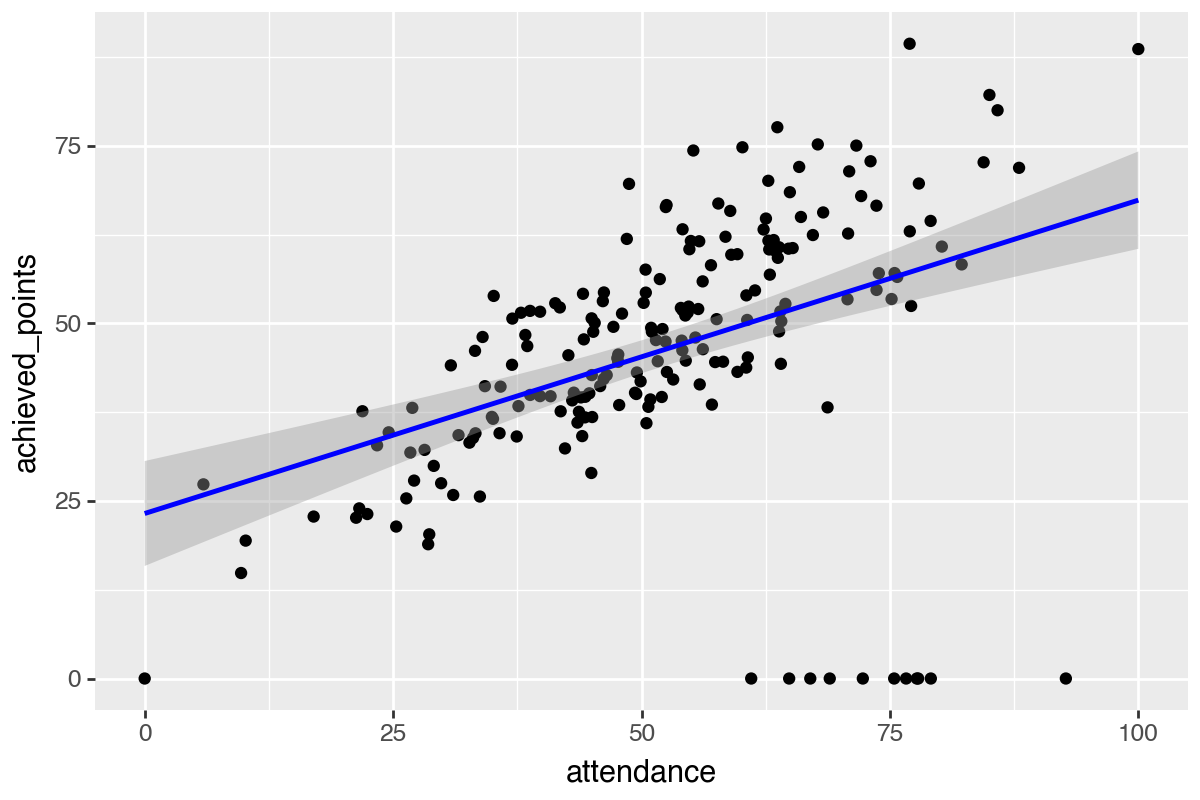

In [114]:
(
    ggplot(exam_df, aes('attendance', 'achieved_points')) + 
    geom_point() + 
    geom_smooth(method = 'lm', color = 'blue') + 
    theme(figure_size=(6,4))
)

Since we do see some outliers in our dataset, the Spearman method should be used. The Spearman
method is robust against outliers within the dataset.

# Section 06 - Let’s do a test

1. Consider the dataset mpg from seaborn, which has an entries about different cars and their characteristics. 

Which statistical test that we studied do you suggest to test the association between the
variable cylinder > 4 and the variable horsepower > 150? Justify the choice of the test and provide
the two-sided p-value.

In [117]:
import seaborn as sns

mpg = sns.load_dataset('mpg').dropna()
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


To be able to choose a test we need to see what kind of data is in our variables. Clearly both variables
are binary, thus we know we need a Fisher test!

For Fisher exact test we have to create a contingency table (2x2 Matrix). This can be done using
crosstab function from pandas:

In [118]:
cont_tbl = pd.crosstab(
    mpg['cylinders'] > 4,
    mpg['horsepower'] > 150
)

cont_tbl

horsepower,False,True
cylinders,,
False,203,0
True,144,45


Now let’s run fisher_exact and extract p-value:

In [124]:
from scipy.stats import fisher_exact

odds_ratio, p_val = fisher_exact(cont_tbl, alternative= 'two-sided')

p_val

np.float64(2.545628945462251e-16)

2. Assume that 𝛼 = 0.05 is our threshold of significance. What did we show in part (1) of this exercise?

Solution:
We showed that we can reject the null hypothesis of no association between these two variables.


3. If (1) had asked us to “test if there is a positive association between the variable cylinder > 4 and
the variable horsepower > 150”, how would our answer change? What do we conclude?

To test for a positive association we thus need alternative = 'greater'.

In [125]:
odds_ratio, p_value = fisher_exact(cont_tbl, alternative = 'greater')
p_value

np.float64(2.545628945462251e-16)

Thus, we find evidence for positive association between these two variables.

4. If (1) had additionally specified “do not make any assumption of normality”, how would our answer
change?

Solution:
This is irrelevant for a Fisher test, therefore we don’t need to change anything.

# Section 07 - Football tournaments

1. FC Gagneurlab is a football team in datavizland. Your friend argues that the probability of FC
gagneurlab winning a match is always one-third - the team either wins or draws or loses. 

You watch six matches inolving FC Gagneurlab, randomly selected throughout the season, and each time FC Gagneurlab won. using this data you collected, can you suggest a statistical test with the assertion of your
friend as null hypothesis? What do you conclude from running this test?

In [126]:
from scipy.stats import binomtest

binomtest(k=6, n=6, p=1/3).pvalue

np.float64(0.0013717421124828527)

The data suggests we can reject the null hypothesis that FC Gagneurlab has a 1/3:1/3:1/3 chance of
winning, losing or having a draw.

2. The dataviz cup is organized as an elimination tournament. 64 teams enter the competition and are
paired up randomly. In each round, the winner in each pairing advances to the next round, whereas the
losing team is eliminated from the competition. There are no draws. This means that whatever team
has won this competition must have won 6 matches in a row. Your friend argues that actually all the
teams in the competition had a 50% chance of winning each of their matches. Would running the same
test as in (1) with p = 0.5 for the winning team already suffice to reject this null hypothesis? Why or
why not?

In [128]:
binomtest(k = 6, n = 6, p = 0.5).pvalue

np.float64(0.03125)

Solution:
No, the issue is that one team always has to win.

Knowing that some team won 6 out of 6 matches does not actually provide any information here.

Only looking at the winning team once we know the winning team, is a case of data snooping.

3. The following table shows the results of nine randomly selected football games from datavizland,
recording the score of the home team and the away team in each match. Your friend thinks that playing
at home confers a slight advantage and thus home teams are more likely to win than one would expect
by chance. Test this hypothesis.

In [130]:
games = pd.DataFrame({
'match': range(1, 10),
'Home' : [3,4,4,5,4,2,1,2,0],
'Away': [0,1,0,0,1,3,2,3,1]
})
games

,match,Home,Away
0,1,3,0
1,2,4,1
2,3,4,0
3,4,5,0
4,5,4,1
5,6,2,3
6,7,1,2
7,8,2,3
8,9,0,1


In [134]:
games['winner'] = np.where(games['Home'] - games['Away'] > 0, 1 , 0)
games

,match,Home,Away,winner
0,1,3,0,1
1,2,4,1,1
2,3,4,0,1
3,4,5,0,1
4,5,4,1,1
5,6,2,3,0
6,7,1,2,0
7,8,2,3,0
8,9,0,1,0


In [144]:
binomtest(k = games['winner'].sum(), n = games.shape[0], p = 1/3)

BinomTestResult(k=5, n=9, alternative='two-sided', statistic=0.5555555555555556, pvalue=0.17085810089925316)

4. Your friend argues that this table is not tidy. Thus your friend proposes to reshape the table and run
the following test:

In [145]:
games['HomeWin'] = games['Home'] > games['Away']
games['AwayLoss'] = games['Home'] < games['Away']

games_melted = pd.melt(games[['HomeWin', 'AwayLoss']])

pval = binomtest(k = (games_melted[games_melted.variable == 'HomeWin'].value.sum()
+ games_melted[(games_melted.variable == 'AwayLoss')&(games_melted.value == False)].shape[0]),
n = games_melted.shape[0],
p = 1/3,
alternative = 'greater').pvalue

print(pval)

0.04334806618862122


Based on this code, he argues that we can reject the null hypothesis that there is no home advantage.
What does your friend’s code do? Do you agree with this analysis? If not, can you point out a concrete
statistical flaw?

Solution:
The issue with this analysis is that the i.i.d. assumption is not respected. Specifically, for each match,
if home wins then away must have lost. Thus the “AwayLoss” is not an independent sample from the
“HomeWin”, so this reshape artificially increases the sample size and thereby distorts the P-value.

5. Your friend now points you to the following code:

In [146]:
from scipy.stats import ttest_ind

pval = ttest_ind(games['Home'], games['Away'], equal_var=True, alternative = 'greater').pvalue
print(pval)

0.017837055301797015


He argues that this clearly rejects the null hypothesis that home teams are not more likely to win than
one would expect by chance. Do you agree with this analysis or can you point out concrete statistical
flaws?

Solution:

Firstly, this assumes that the average number of goals of the home and away teams follow a normal
distribution, which is dubious given that goals are discrete and non-negative .

Given the small sample size, invoking the CLT here will also be highly dubious.

More importantly, this test has a different null hypothesis. Specifically the null hypothesis is that the
home team does not shoot more goals on average.

This is similar to the null hypothesis of no home advantage in winning, as more goals usually will be
associated with a win.

But one can imagine scenarios where, e.g., win probabilities are equal, but conditional on a win, the
home team scores more goals.